# Explore v10 dataset
Minimal scaffolding: load one trial npz, peek at state, images, and contacts.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
DATASET_ROOT = Path('../datasets/v10')
SCENE = 'scene_level2'
TASK = 'clean_nominal'

task_dir = DATASET_ROOT / SCENE / TASK
manifest = pd.read_csv(task_dir / 'manifest.csv')
print('rows:', len(manifest))
manifest.head()

rows: 241


,experiment_id,task_id,traj_id,trajectory_file,seed,traj_progress,num_contacts,num_failure_modes,had_any_collision,impacted_geom_ids,pre_qvel_norm,npz_file
0,exp_000250,clean_nominal,0,scene_level2_clean_nominal_00.pkl,20260674,0.0131,47795,6,True,0;86;87;88;89;90;91;92;93;94;95;96,6.7026,exp_000250.npz
1,exp_000251,clean_nominal,0,scene_level2_clean_nominal_00.pkl,20260675,0.1556,52257,6,True,0;65;70;71;72;73;74;75;79;80;81;85;86;87;88;89...,1.4345,exp_000251.npz
2,exp_000252,clean_nominal,0,scene_level2_clean_nominal_00.pkl,20260676,0.0876,48013,6,True,0;65;93;94;95;96,1.9705,exp_000252.npz
3,exp_000253,clean_nominal,0,scene_level2_clean_nominal_00.pkl,20260677,0.0712,48000,6,True,0;93;94;95;96,1.8873,exp_000253.npz
4,exp_000254,clean_nominal,0,scene_level2_clean_nominal_00.pkl,20260678,0.1368,55381,6,True,0;65;70;71;72;73;74;75;78;79;80;81;82;85;86;87...,1.6986,exp_000254.npz


In [3]:
row = manifest.iloc[0]
data = np.load(task_dir / row.npz_file, allow_pickle=True)
for k in data.files:
    a = data[k]
    print(f'{k:24s} {str(a.dtype):12s} {a.shape}')

pre_rgb                  uint8        (480, 640, 3)
pre_qpos                 float64      (7,)
pre_qvel                 float64      (7,)
pre_ee_pos               float64      (3,)
pre_gripper_ctrl         float64      (1,)
contact_positions        float32      (47795, 3)
contact_forces           float32      (47795, 6)
contact_geom_pairs       int32        (47795, 2)
contact_failure_id       int32        (47795,)
failure_modes            <U13         (6,)
failure_probs            float32      (6,)
impacted_geom_ids        int32        (12,)
task_id                  <U13         (1,)
traj_id                  int32        (1,)
traj_progress            float32      (1,)
seed                     int32        (1,)
pre_qvel_norm            float64      (1,)
pre_depth                float32      (480, 640)
ee_cam_rgb               uint8        (480, 640, 3)
ee_cam_depth             float32      (480, 640)
post_rgb                 uint8        (480, 640, 3)


## State

In [4]:
print('task_id        :', data['task_id'])
print('traj_id        :', data['traj_id'])
print('traj_progress  :', data['traj_progress'])
print('pre_qpos       :', data['pre_qpos'])
print('pre_qvel       :', data['pre_qvel'])
print('pre_ee_pos     :', data['pre_ee_pos'])

task_id        : ['clean_nominal']
traj_id        : [0]
traj_progress  : [0.01309282]
pre_qpos       : [ 0.004675    0.03411721  0.01367328 -1.21459005 -0.01153363  0.19701569
 -0.01127461]
pre_qvel       : [ 0.06050171  0.50249066  0.24072311  6.67531321 -0.18710376  0.07439822
 -0.10087832]
pre_ee_pos     : [0.29522593 0.00373718 0.66553105]


## Images

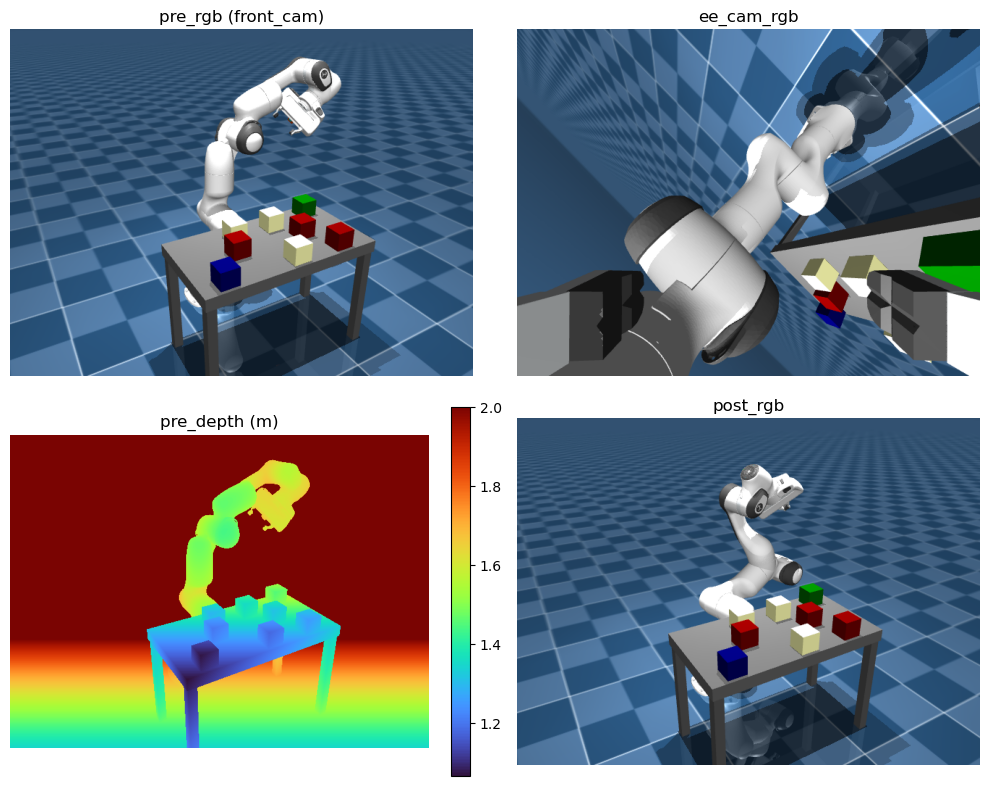

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0, 0].imshow(data['pre_rgb']);     axes[0, 0].set_title('pre_rgb (front_cam)')
axes[0, 1].imshow(data['ee_cam_rgb']);  axes[0, 1].set_title('ee_cam_rgb')

depth = data['pre_depth']
im = axes[1, 0].imshow(np.clip(depth, 0.05, 2.0), cmap='turbo')
axes[1, 0].set_title('pre_depth (m)')
plt.colorbar(im, ax=axes[1, 0], fraction=0.046)

axes[1, 1].imshow(data['post_rgb']);    axes[1, 1].set_title('post_rgb')

for ax in axes.flat:
    ax.axis('off')
plt.tight_layout()

## Contacts

In [ ]:
pos = data['contact_positions']     # (N, 3)
forces = data['contact_forces']      # (N, 6) — first 3 are linear force
pairs = data['contact_geom_pairs']   # (N, 2)
fid = data['contact_failure_id']     # (N,)
modes = data['failure_modes']
probs = data['failure_probs']

print('num contacts   :', pos.shape[0])
print('failure_modes  :', modes)
print('failure_probs  :', probs)

fmag = np.linalg.norm(forces[:, :3], axis=1)
print('\nfirst 5 contacts:')
for i in range(min(5, len(pos))):
    print(f'  pos={pos[i]}  |F|={fmag[i]:.2f}N  pair={pairs[i]}  fail_id={fid[i]}')

num contacts   : 47795
failure_modes  : ['gripper_open' 'slippery_grip' 'single_joint' 'single_joint'
 'multi_joint' 'all_joints']
failure_probs  : [0.35 0.25 0.15 0.1  0.1  0.05]

first 5 contacts:
  pos=[-2.6500002e-01 -4.7499999e-01 -1.6300588e-05]  |F|=6.57N  pair=[ 0 93]  fail_id=0
  pos=[-2.9499999e-01 -4.7499999e-01 -1.6278085e-05]  |F|=6.57N  pair=[ 0 93]  fail_id=0
  pos=[-2.6500002e-01 -5.0500000e-01 -1.6355147e-05]  |F|=6.60N  pair=[ 0 93]  fail_id=0
  pos=[-2.9499999e-01 -5.0500000e-01 -1.6332644e-05]  |F|=6.59N  pair=[ 0 93]  fail_id=0
  pos=[ 2.9499999e-01 -4.7499999e-01 -1.6720629e-05]  |F|=6.74N  pair=[ 0 94]  fail_id=0


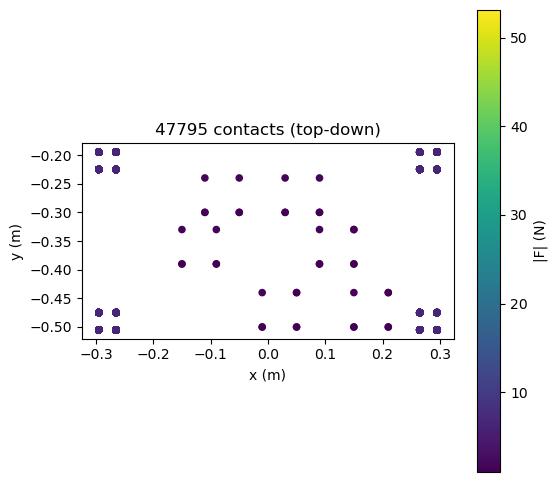

In [7]:
if len(pos) > 0:
    fig, ax = plt.subplots(figsize=(6, 6))
    sc = ax.scatter(pos[:, 0], pos[:, 1], c=fmag, cmap='viridis', s=20)
    ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)'); ax.set_aspect('equal')
    ax.set_title(f'{len(pos)} contacts (top-down)')
    plt.colorbar(sc, ax=ax, label='|F| (N)')